## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:0'

%load_ext autoreload
%autoreload 2

## Data generation

In [2]:
from datasets.Student_t import MultivariateStudentT

d = 64
dim_x = dim_y = d//2
rho = 0.7
df = 2
mean = np.zeros(dim_x + dim_y)
V = np.eye(dim_x)*rho
dispersion = np.eye(dim_x + dim_y)
dispersion[0:dim_x, :][:, dim_x:] = V
dispersion[dim_x:, :][:, 0:dim_x] = V


dataset = MultivariateStudentT(
        dim_x=dim_x,
        dim_y=dim_y,
        mean=mean,
        dispersion=dispersion,
        df=df)

X, Y = dataset.sample(10000)
X, Y = torch.Tensor(X).float().to(device), torch.Tensor(Y).float().to(device)

print(f'MI is {dataset.mutual_information(): 0.2f}')
print('X', X.shape, 'Y', Y.shape)

MI is  12.00
X torch.Size([10000, 32]) Y torch.Size([10000, 32])


## Train the VCE estimator

In [3]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [4]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', dataset.mutual_information())
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 1.379530668258667 loss val= 1.9407567977905273 best val loss= 1.9407567977905273 best t= 0
finished: t= 126 loss= 1.0395044088363647 loss val= 1.2632098197937012 best val loss= 1.1956820487976074 best t= 95
finished: t= 252 loss= 1.0280704498291016 loss val= 1.3319599628448486 best val loss= 1.178524374961853 best t= 192
finished: t= 378 loss= 1.1291927099227905 loss val= 1.3013181686401367 best val loss= 1.178524374961853 best t= 192


finished: t= 0 loss= 1.4966660737991333 loss val= 1.9259660243988037 best val loss= 1.9259660243988037 best t= 0
finished: t= 126 loss= 1.1076505184173584 loss val= 1.2937440872192383 best val loss= 1.2281560897827148 best t= 100
finished: t= 252 loss= 1.1862190961837769 loss val= 1.2512407302856445 best val loss= 1.1832940578460693 best t= 250
finished: t= 378 loss= 0.9039126634597778 loss val= 1.3099592924118042 best val loss= 1.1832940578460693 best t= 250


finished: t= 0 loss=

### Check the computed vector ranks

In [7]:
import torch.distributions as distribution

XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
U = (U-U.mean(keepdim=True, dim=0))/U.std(keepdim=True, dim=0)


V = torch.matmul(U.t(), U)/(len(U)+1)

### Visualizing the distributions of non-diagonal elements

mean abs 0.02436834107203492
q5 -0.038012612611055374
q95 0.04206160083413124


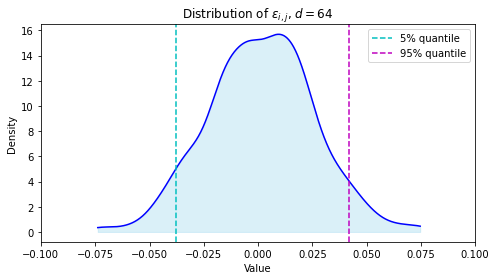

In [10]:
from scipy.stats import gaussian_kde


# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=64$')
plt.xlim(-0.10, 0.10)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()